# Prepare & Sample Gold Standard Dataset

## Overview
Todo

## Environment Setup
Installs the required packages and sets up config values.

_Note: `%%capture` disables the output of the pip install cell below. If you encounter any installation errors, please remove that line._

In [12]:
%%capture 

%pip install matplotlib pandas presidio_analyzer presidio_anonymizer nltk faker pandarallel tqdm ipywidgets ipykernel seaborn awswrangler
%pip install --upgrade nbformat

In [47]:
# Imports
import datetime

import pandas as pd
import numpy as np
import json
import re

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.notebook import tqdm
from tqdm import tqdm
from pandarallel import pandarallel

import boto3
import awswrangler as wr

import nltk
from collections import Counter
from nltk.corpus import words

from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
from faker import Faker

In [14]:
# Constants
RANDOM_STATE = 42
TARGET_TOTAL = 2000
TARGET_PER_CAT = 45

# AWS
AWS_REGION = "eu-west-2"
AWS_PROFILE = "data-platform-housing-prod"
DATABASE_NAME = "housing-refined-zone"
TABLE_NAME = "additional_needs_notes_reshaped"


## Construct Taxonomy
Map the hierarchical 'Additional Needs' categories from the CSV file into snake case labels.

In [15]:
def parse_taxonomy_csv():
    """Parse and clean the taxonomy csv"""
    df = pd.read_csv("data/input/Additional needs taxonomy.csv", usecols=['Very high level category', 'Category', 'Description (attribute)', 'Value (of data type)'])
    df.dropna(inplace=True)
    columns_rename = {
        'Very high level category': 'top_level_category',
        'Category': 'high_level_category',
        'Description (attribute)': 'category_description',
        'Value (of data type)': 'values_hint'
    }
    df.rename(columns=columns_rename, inplace=True)
    df['values_hint'] = df['values_hint'].str.split("\n")
    return df

def make_label(*parts):
    """Create a snake_case label from multiple parts (stripping special characters)"""
    label = '_'.join(p.strip().strip("'\"()[]{}") for p in parts).lower()
    label = re.sub(r'[\s]+', '_', label)
    label = re.sub(r'[^a-z0-9_]', '', label)
    return re.sub(r'_+', '_', label)

taxonomy = parse_taxonomy_csv()
# Autogenerated labels - format: cat_<top_level_category>_<high_level_category>_<category>
taxonomy['high_level_cat_label'] = taxonomy.apply(
    lambda row: 'cat_' + make_label(row['top_level_category'], row['high_level_category']), axis=1)
taxonomy['cat_label'] = taxonomy.apply(
    lambda row: make_label(row['high_level_cat_label'], row['category_description']), axis=1)

In [16]:
taxonomy.head()

,top_level_category,high_level_category,category_description,values_hint,high_level_cat_label,cat_label
0,Disability,Disability,Sensory,"[Deaf, Hearing impairment, Visually impaired, ...",cat_disability_disability,cat_disability_disability_sensory
1,Disability,Mobility,Physical disability,"[Wheelchair user, Limited mobility (could be a...",cat_disability_mobility,cat_disability_mobility_physical_disability
2,Disability,Adaptation,Requires adapted property,"[Minor adaptations, Major adaptation]",cat_disability_adaptation,cat_disability_adaptation_requires_adapted_pro...
3,Safety & Risk,Safety & Risk,Domestic abuse,"[Alleged Perpetrator, Survivor]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_domestic_abuse
4,Safety & Risk,Safety & Risk,Fire-related risks,"[Arson, Fire hazards in the house]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_firerelated_risks


In [17]:
taxonomy.to_csv("data/output/taxonomy_autogen_labels.csv", index=False)

### Regex Mapping Logic

Create regexes for each category.

Initial labels are assigned using regular expressions based on conversations with Housing Officers. 

This provides a 'weak classification' foundation for the class imbalance analysis and subsequent stratified sampling.

<style scoped>
table {
  font-size: 11px;
}
</style>

| **Category** | **Keywords & Patterns** |
| :--- | :--- |
| **DISABILITY** | |
| Sensory | `deaf, BSL, hearing loss/impairment/aid, hard of hearing, blind, partially sighted, visual impairment` |
| Physical Mobility | `frail, history of falls, poor mobility, walking frame/aid/stick, zimmer (zimmer frame)` |
| Property Adaptations | `stairlift, wet room, level access, minor adaptation` |
| **SAFETY & RISK** | |
| Domestic Abuse | `domestic abuse, domestic violence, DV, coercive control, IDVA, DA` |
| Fire Risks,"arson | `arson, fire hazard, fire risk, fire safety, no smoke alarm, candles` |
| Exploitation | `cuckooing, financial abuse/exploitation, sexual exploitation, criminal exploitation, modern slavery, trafficking` |
| Youth Violence | `gang member/affiliated/involvement, targeted by gang, gang indimidation/threats` |
| Anti-Social Behaviour | `ASB, anti-social, harassment, hate crime, nuisance` |
| Children at Risk | `child/children at risk, child protection, safeguarding child/children, Section 47, S47` |
| Criminal Activity | `criminal activity/behaviour/record, offending, arrested, convicted, caution` |
| Violence | `violent/violence, assault(ed), attack(ed), threaten(ed), stabb(ing/ed), weapon` |
| Gas Safety | `gas capped, gas cap` |
| Home Unsuitable from a Medical Perspective | `street homeless, sleeping rough, no fixed abode, sofa surfing` |
| **ADDICTION** | |
| Gambling | `gambling, betting, bookmaker` |
| Substance Misuse | `alcohol, drinking, drunk, booze, alcholic, drugs, cocaine, heroin, crack, cannabis, methadone, addict(ed)` |
| **CARE** | |
| Care Leaver (over 25)| `care experienced, care leaver, aged out of care` |
| Care Leavers (under 25) | `looked after, foster` |
| Care Settings | `fostered, foster care, foster placement, in care, care placement, social care placement` |
| Support Services | `social care, care package, care plan, care coordinator` |
| Caring Responsiblities | `formal carer, registered carer, carer's allowance, unpaid carer, caring for, looking after` |
| **COMMUNICATION** | |
| Digital Exclusion | `no internet, no wifi, digitally excluded, no phone/device/computer/laptop, digital exclusion` |
| English Fluency | `low literacy, language barrier, interpreter, translation, no english, limited english, ESOL` |
| Specialized Needs | `BSL, braille, sign language, hearing loop, induction loop, large print, audio forrmat, screen reader, communication support, speech impairment, augmentive, alternative communication, AAC` |
| **FINANCIAL** | |
| Income Status | `unemployed, long-term unemployment, ESA, Universal Credit, not working, benefit check, incorrect benefit` |
| Cost of Living | `foodbank, food parcel, fuel poverty, can't afford, heading/costs/bills, prepayment meter` |
| Financial Oversight | `CFAT, client financial affairs, appointeeship` |
| **HEALTH** | |
| Critical Illness | `terminal, end of life, palliative, hospice` |
| Medical Settings | `hospice, nursing home, care home, residential home, in hospital, hospitalised, admitted to hospital, inpatient, staying/livng with family/friends` |
| Mental Capacity | `advocate, IMCA, deputy, court of protection, LPA, power of attorney, next of kin` |
| Neurodiversity | `autism, ASD, Asperger, ADHD, dyslexia, learning disability` |
| Cognitive Health | `dementia, Alzheimer, memory loss, cognitive impairment` |
| Reproductive | `pregnant, pregnancy, stillbirth, miscarriage, menopause, postnatal` |
| Very young children | `newborn, infant, toddler, very young child, baby` |
| Respiratory | `asthma, inhaler, COPD, chronic obstructive, allergy, breathlessness` |
| Mental Health | `suicidal, self-harm, depression, anxiety, panic attack, PTSD, mental health, low mood` |
| Poor Health | `frail, chronic illness/condition/pain, weakened immune system, immunocompromised` |
| Children EHCP (Education, Health and Care Plan) | `EHCP, education health and care, SEN, SEND, special educational needs` |
| **HOUSING CONDITIONS** | |
| Basic Needs | `no gas, no electric, no water\gas, cut off. disconnected, power cut/off` |
| Disrepair | `disrepair, unfit, unhabitable, repair, broken, damaged, leaking` |
| Infestation | `rats, mouse, mice, vermin, pest, bed bug, cockroach, flea, daddy long legs, silverfish` |
| Dangerous Animals | `dangerous dog, dog attack, dog bite, aggressive dog, dangerous pet/animal` |
| Self Neglect | `clutter, hoarding, hoarder, self-neglect, squalor, unclean` |
| Damp & Mould | `damp, mould, mold, condensation, leak, black mould` |
| Overcrowding | `overcrowding, awaiting rehousing, home swap, mutual exchange, housing list, bidding` |
| **LIFE EVENTS** | |
| Identity | `refugee, asylum seeker, NRPF, leave to remain` |
| Former Refugee or Asylum Seeker | `refugee, asylum seeker, NRPF, leave to remain` |
| Ex-service personnel | `refugee, asylum seeker, NRPF, leave to remain` |
| Prison / Probation | `released from prison, licence, probation, HMP, remanded` |
| Homelessness | `street homeless, sleeping rough, no fixed abode, sofa surfing` |
| **MOBILITY** | |
| Mobility | `wheelchair, physical disability, physically disabled, amputee, paralysis, crutch(es), broken leg/ankle/hip/arm, post-op, recovering from surgery/operation` |

In [18]:
def construct_category_regexes(taxonomy_df):
    # category names match taxonomy cat_label
    category_regex_dict = {
        # --- TL: Disability ---
        "cat_disability_disability_sensory": r"\bdeaf\b|\bBSL\b|\bhearing (?:loss|impairment|aid)\b|\bhard of hearing\b|\bblind\w*\b|\bpartially sighted\b|\bvisual impairment\b",
        "cat_disability_mobility_physical_disability": r"\bfrail\w*\b|\bhistory of falls\b|\bpoor mobility\b|\bwalking (?:frame|aid|stick)\b|\bZimmer\b",
        "cat_disability_adaptation_requires_adapted_property": r"\bstairlift\b|\bwet room\b|\blevel access\b|\bminor adaptation\w*\b|\bmajor adaptation\w*\b",
        
        # --- TL: Safety & Risk ---
        "cat_safety_risk_safety_risk_domestic_abuse": r"\bdomestic abuse\b|\bdomestic violence\b|\bDV\b|\bcoercive control\b|\bIDVA\b|\bDA\b",
        "cat_safety_risk_safety_risk_firerelated_risks": r"\barson\b|\bfire hazard\b|\bfire risk\b|\bfire safety\b|\bno smoke alarm\b|\bcandles?\b",
        "cat_safety_risk_safety_risk_risk_of_exploitation": r"\bcuckooing\b|\bfinancial (?:exploitation|abuse)\b|\bsexual exploitation\b|\bcriminal exploitation\b|\bmodern slavery\b|\btraffick\w*\b",
        "cat_safety_risk_safety_risk_serious_youth_violence": r"\bgang (?:member|affiliated|involvement)\b|\btargeted by gang\b|\bgang (?:intimidation|threats)\b",
        "cat_safety_risk_safety_risk_antisocial_behaviour": r"\bASB\b|\banti-social\b|\bharassment\b|\bhate crime\b|\bnuisance\b",
        "cat_safety_risk_safety_risk_children_at_risk": r"\bchildren? at risk\b|\bchild protection\b|\bsafeguarding (?:child|children)\b|\bSection 47\b|\bS47\b",
        "cat_safety_risk_safety_risk_criminal_activity": r"\bcriminal (?:activity|behaviour|record)\b|\boffend\w*\b|\barrested\b|\bconvicted\b|\bcaution\b",
        "cat_safety_risk_safety_risk_violence": r"\bviolen\w*\b|\bassault\w*\b|\battack\w*\b|\bthreaten\w*\b|\bstabb\w*\b|\bweapon\b",
        "cat_safety_risk_safety_risk_gas_capped": r"\bgas (?:capped|cap)\b",
        "cat_vulnerability_safety_risk_home_unsuitable_from_a_medical_perspective": r"\bhome unsuitable\b|\bmedically unsuitable\b|\bproperty unsuitable\b",
        
        # --- TL: Vulnerability ---
        # --- HL: Addiction ---
        "cat_vulnerability_addiction_gambling": r"\bgambl\w*\b|\bbetting\b|\bbookmaker\b",
        "cat_vulnerability_addiction_substance_misuse": r"\balcohol\w*\b|\bdrinking\b|\bdrunk\w*\b|\bbooze\b|\balcoholic\b|\bdrug\w*\b|\bcocaine\b|\bheroin\b|\bcrack\b|\bcannabis\b|\bmethadone\b|\baddic\w*\b",
        
        # --- HL: Care ---
        "cat_vulnerability_care_care_experienced_over_25": r"\bcare experienced\b|\bcare leaver\b|\baged out of care\b",
        "cat_vulnerability_care_care_leaver_or_looked_after_under_25": r"\blooked after\b|\blooked-after\b|\bfoster\w*\b",
        "cat_vulnerability_care_care_setting": r"\bfostered\b|\bfoster care\b|\bfoster placement\b|\bin care\b|\bcare placement\b|\bsocial care placement\b",
        "cat_vulnerability_care_social_care_involvement": r"\bsocial care\b|\bcare package\b|\bcare plan\b|\bcare coordinator\b",
        "cat_vulnerability_care_has_caring_responsibility": r"\bformal carer\b|\bregistered carer\b|\bcarer.s allowance\b|\bunpaid carer\b|\bcaring for\b|\blooking after\b",
        
        # --- HL: Communication ---
        "cat_vulnerability_communication_needs_digital_exclusion": r"\bno internet\b|\bno wifi\b|\bdigitally excluded\b|\bno (?:phone|device|computer|laptop|tablet)\b|\bdigital exclusion\b",
        "cat_vulnerability_communication_needs_fluency_in_english": r"\blow literacy\b|\blanguage barrier\b|\binterpreter\b|\btranslation\b|\bno English\b|\blimited English\b|\bESOL\b",
        "cat_service_need_communication_needs_communication_needs": r"\bBSL\b|\bbraille\b|\bsign language\b|\bhearing loop\b|\binduction loop\b|\blarge print\b|\baudio format\b|\bscreen reader\b|\bcommunication support\b|\bspeech impairment\b|\baugmentative\b|\balternative communication\b|\bAAC\b",

        # --- HL: Financial ---
        "cat_vulnerability_financial_income_status": r"\bunemployed\b|\blong.term unemploy\w*\b|\bESA\b|\bUniversal Credit\b|\bnot working\b|\bbenefit check\b|\bincorrect benefit\w*\b",
        "cat_vulnerability_financial_cost_of_living": r"\bfood.?bank\b|\bfood parcel\b|\bfuel poverty\b|\bcan.t afford\b|\bheating (?:costs|bills)\b|\bprepay\w* meter\b",
        "cat_vulnerability_financial_client_financial_affairs_team": r"\bCFAT\b|\bclient financial affairs\b|\bappointeeship\b",
        
        # --- HL: Health ---
        "cat_vulnerability_health_terminally_ill": r"\bterminal\w*\b|\bend of life\b|\bpalliative\b|\bhospice\b",
        "cat_vulnerability_health_care_setting": r"\bhospice\b|\bnursing home\b|\bcare home\b|\bresidential home\b|\bin hospital\b|\bhospitalised\b|\badmitted to hospital\b|\binpatient\b|\bstaying with (?:family|relatives|friends)\b|\bliving with (?:family|relatives|friends)\b",
        "cat_vulnerability_health_mental_capacity": r"\badvocate\b|\bIMCA\b|\bdeputy\b|\bcourt of protection\b|\bLPA\b|\bpower of attorney\b|\bnext of kin\b",
        "cat_vulnerability_health_neurodiversity_learning_disability": r"\bautis\w*\b|\bASD\b|\bAsperger\w*\b|\bADHD\b|\battention deficit\b|\bdyslexia\b|\blearning disabilit\w*\b",
        "cat_vulnerability_health_cognitive_impairment": r"\bdementia\b|\bAlzheimer\w*\b|\bmemory loss\b|\bcognitive impairment\b",
        "cat_vulnerability_health_reproductive": r"\bpregnant\b|\bpregnancy\b|\bstillbirth\b|\bmiscarriage\b|\bmenopause\b|\bpostnatal\b",
        "cat_vulnerability_health_very_young_children_in_household": r"\bnewborn\b|\binfant\b|\btoddler\b|\bvery young child\b|\bbaby\b",
        "cat_vulnerability_health_breathing_respiratory_problems": r"\basthma\b|\binhaler\b|\bCOPD\b|\bchronic obstructive\b|\ballerg\w*\b|\bbreathless\w*\b",
        "cat_vulnerability_health_mental_health": r"\bsuicidal\b|\bself.harm\b|\bdepress\w*\b|\banxiet\w*\b|\bpanic attack\b|\bPTSD\b|\bmental health\b|\blow mood\b",
        "cat_vulnerability_health_social_isolation": r"\blonely\b|\bloneliness\b|\bsocially isolated\b|\bisolat\w*\b|\bno social contact\b",
        "cat_vulnerability_health_poor_health": r"\bfrail\w*\b|\bchronic (?:illness|condition|pain)\b|\bweakened immune\b|\bimmunocompromised\b",
        "cat_vulnerability_health_children_ehcp_education_health_and_care_plan": r"\bEHCP\b|\beducation health and care\b|\bSEN\b|\bSEND\b|\bspecial educational needs\b",

        # --- HL: Housing Conditions ---
        "cat_vulnerability_housing_conditions_basic_needs": r"\bno gas\b|\bno electric\w*\b|\bno water\b|\bgas (?:cut off|disconnected)\b|\bpower (?:cut|off)\b",
        "cat_vulnerability_housing_conditions_home_in_disrepair": r"\bdisrepair\b|\bunfit\b|\bunhabitable\b|\brepair\w*\b|\bbroken\b|\bdamaged\b|\bleaking\b",
        "cat_vulnerability_housing_conditions_infestation": r"\brat\w*\b|\bmice\b|\bmouse\b|\bvermin\b|\bpest\w*\b|\bbed bug\w*\b|\bcockroach\w*\b|\bflea\w*\b|\bdaddy long.?legs\b|\bsilverfish\b",
        "cat_vulnerability_housing_conditions_dangerous_animals": r"\bdangerous dog\b|\bdog attack\b|\bdog bite\b|\baggressive dog\b|\bdangerous (?:pet|animal)\b",
        "cat_vulnerability_housing_conditions_selfneglect": r"\bclutter\w*\b|\bhoarding\b|\bhoarder\b|\bself.neglect\b|\bsqualor\b|\bunclean\b",
        "cat_vulnerability_housing_conditions_damp_mould": r"\bdamp\b|\bmould\b|\bmold\b|\bcondensation\b|\bleak\w*\b|\bblack mould\b",
        "cat_vulnerability_housing_conditions_overcrowding": r"\bovercrowd\w*\b|\bawaiting rehousing\b|\bhome swap\b|\bmutual exchange\b|\bhousing list\b|\bbidding\b",

        # --- HL: Life Events ---
        "cat_vulnerability_life_events_identity": r"\btransgender\b|\btrans (?:woman|man|person)\b|\bnon.binary\b|\bgender dysphoria\b",
        "cat_vulnerability_life_events_former_refugee_asylum_seeker": r"\brefugee\b|\basylum seeker\b|\bNRPF\b|\bno recourse\b|\bleave to remain\b",
        "cat_vulnerability_life_events_ex_service_personnel": r"\bveteran\b|\bex.service\b|\barmed forces\b|\bformer (?:soldier|military|army|navy|RAF)\b",
        "cat_vulnerability_life_events_bereavement": r"\bbereavement\b|\bbereaved\b|\bgrief\b|\bgrieving\b|\bpassed away\b|\bdeath of\b",
        "cat_vulnerability_life_events_left_institution": r"\breleased from prison\b|\bon (?:licence|probation)\b|\bprobation\b|\bdischarged from hospital\b|\bleft (?:refuge|supported housing)\b",
        "cat_vulnerability_life_events_currently_rehoused_decanted": r"\btemporary accommodation\b|\btemp accom\b|\bdecant\w*\b|\bB&B\b|\bhostel\b",
        "cat_vulnerability_life_events_in_prison": r"\bcurrently in prison\b|\bin (?:custody|jail|prison)\b|\bremanded\b|\bHMP\b",
        "cat_vulnerability_life_events_homelessness": r"\bstreet homeless\b|\bsleeping rough\b|\brough sleep\w*\b|\bno fixed abode\b|\bNFA\b|\bsofa surf\w*\b",
        
        # --- HL: Mobility ---
        "cat_vulnerability_mobility_mobility": r"\bwheelchair\b|\bphysical disabilit\w*\b|\bphysically disabled\b|\bamputee\b|\bparalys\w*\b|\bcrutch\w*\b|\bbroken (?:leg|ankle|hip|arm)\b|\bpost.op\b|\brecovering from (?:surgery|operation)\b",
    }

    # Merge taxonomy with regexes
    regex_df = pd.DataFrame(list(category_regex_dict.items()), columns=['cat_label', 'regex'])
    df = taxonomy_df.merge(regex_df, on='cat_label', how='inner')
    if len(df) != len(category_regex_dict):
        print("Labels in regex dict that don't match taxonomy:", set(category_regex_dict.keys()) - set(df['cat_label']))
        raise Exception(f"Mismatch between taxonomy and regex dict - check category labels")
    return df

taxonomy = construct_category_regexes(taxonomy)

In [19]:
taxonomy.to_csv("data/output/taxonomy_autogen_labels.csv", index=False)
taxonomy.head()

,top_level_category,high_level_category,category_description,values_hint,high_level_cat_label,cat_label,regex
0,Disability,Disability,Sensory,"[Deaf, Hearing impairment, Visually impaired, ...",cat_disability_disability,cat_disability_disability_sensory,\bdeaf\b|\bBSL\b|\bhearing (?:loss|impairment|...
1,Disability,Mobility,Physical disability,"[Wheelchair user, Limited mobility (could be a...",cat_disability_mobility,cat_disability_mobility_physical_disability,\bfrail\w*\b|\bhistory of falls\b|\bpoor mobil...
2,Disability,Adaptation,Requires adapted property,"[Minor adaptations, Major adaptation]",cat_disability_adaptation,cat_disability_adaptation_requires_adapted_pro...,\bstairlift\b|\bwet room\b|\blevel access\b|\b...
3,Safety & Risk,Safety & Risk,Domestic abuse,"[Alleged Perpetrator, Survivor]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_domestic_abuse,\bdomestic abuse\b|\bdomestic violence\b|\bDV\...
4,Safety & Risk,Safety & Risk,Fire-related risks,"[Arson, Fire hazards in the house]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_firerelated_risks,\barson\b|\bfire hazard\b|\bfire risk\b|\bfire...


## Acquire Data
Get latest data from AWS Athena.

In [20]:
def fetch_data_from_athena():
    session = boto3.Session(region_name=AWS_REGION, profile_name=AWS_PROFILE)

    sql_query = f''' SELECT DISTINCT note_id, note_content, note_category
                    FROM "{DATABASE_NAME}".{TABLE_NAME}
                    WHERE flag_no_matching_target = FALSE
                        AND flag_note_date_parse_failed = FALSE
                        AND flag_is_organisation = FALSE
                        AND flag_inactive = FALSE;
    '''

    return wr.athena.read_sql_query(sql_query, database=DATABASE_NAME, boto3_session=session, ctas_approach=False)

df = fetch_data_from_athena()

In [21]:
df['note_content'] = "[Category: " + df['note_category'] + "] " + df['note_content']
df.head()

,note_id,note_content,note_category
0,115b63de-5cdd-2243-2fdd-7a6d5623e16b,[Category: Tenure management] Callback success...,Tenure management
1,193a7031-3c51-4aae-a681-0da97f0dc2da,[Category: tenureManagement] email to tnt Dea...,tenureManagement
2,1ef4fd94-ba78-47ac-9ad8-b4dda73a5c68,[Category: tenureManagement] email from tnt \...,tenureManagement
3,395c8fd1-b4ce-32ab-b676-fc45fb94b5b5,[Category: Tenure management] Call Summary; Ca...,Tenure management
4,3ba479ee-aaae-c1ac-566f-25a55c6538a6,[Category: Tenure management] Client in office...,Tenure management


## Expand Acronyms
Discover common acronyms (2-4 letter words that aren't in the English dictionary) and replace them with their expanded forms.

In [22]:
def get_most_common_acronyms(text, n):
    # Load the standard English dictionary into a set
    nltk.download('words')
    english_vocab = set(word.lower() for word in words.words())


    # extract all 2-4 letter words
    short_words = re.findall(r'\b[a-z]{2,4}\b', text)

    # Only keep words NOT in the English dictionary
    jargon_only = [word for word in short_words if word not in english_vocab]

    # 4. Look at the top 100 most common jargon words
    Counter(jargon_only).most_common(n)

get_most_common_acronyms(
    text=" ".join(df['note_content'].dropna().str.lower()), # combine all notes into one string
    n=100
)

[nltk_data] Downloading package words to /Users/arawat/nltk_data...
[nltk_data]   Package words is already up-to-date!


### Replace acronyms
We looked at the common acronyms from the cell above and constructed a *normalisation dictionary*.

| **Acronym** | **Expanded Form** |
| :---------- | :---------------- |
| **HACKNEY TERMS** | |
| HSC | Hackney Service Centre |
| MMH | Manage My Home |
| LBH | London Borough of Hackney |
| RCC | Repairs Contact Centre |
| UH | Universal Housing |
| **HOUSING TERMS** | |
| tnt | tenant |
| clt | client |
| TNTs | tenants |
| clts | clients |
| h/o | housing officer |
| TMO | Tenant Management Organisation |
| NHO | Neighbourhood Housing Officer |
| AHM | Area Housing Manager |
| HB | Housing Benefit |
| NOSP | Notice of Seeking Possession |
| NTQ | Notice to Quit |
| RTB | Right to Buy |
| UC | Universal Credit |
| ASB | anti-social behaviour |
| DV | domestic violence |
| DA | domestic abuse |
| **GENERAL TERMS** | |
| tel | telephone |
| docs | documents |
| appt | appointment |
| acct | account |
| BACS | bank transfer |
| info | information |
| org | organisation |
| sms | text message |
| msg | message |
| CCTV | camera |
| gp | general practitioner |
| pls | please |
| recd | received |
| ASAP | as soon as possible |
| pls | please |
| cert | certificate |

In [23]:
abbreviation_mapping = {
    # Hackney terms
    r'\bhsc\b': 'Hackney Service Centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'Repairs Contact Centre',
    r'\buh\b': 'Universal Housing',
    # r'\buhw\b': 'universal housing ?',
    # r'\buht\b': 'universal housing ?',
    # r'\bncst\b': '??',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\bclt\b': 'client',
    r'\btnts\b': 'tenants',
    r'\bl/h\b': 'leaseholder',
    r'\bh/o\b': 'housing officer',
    r'\btmo\b': 'Tenant Management Organisation',
    # r'\bdlo\b': 'direct labour organisation ??',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    # r'\beo\b': 'estate officer',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'Notice of Seeking Possession',
    r'\bntq\b': 'Notice to Quit',
    r'\brtb\b': 'Right to Buy',
    r'\buc\b': 'Universal Credit',
    r'\basb\b': 'anti-social behaviour',
    # r'\bmpa\b': 'multiple ??',
    # r'\bctax\b': 'council tax',
    r'\bdv\b': 'domestic violence',
    r'\bda\b': 'domestic abuse',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    r'\bvm\b': 'voicemail',
    # r'\bo/s\b': 'outstanding',
    # r'\btc\b': 'telephone call',
    # r'\blm\b': 'left message',
}

In [24]:
pandarallel.initialize(progress_bar=True)
acronym_substitution_patterns = [(re.compile(p, re.IGNORECASE), r) for p, r in abbreviation_mapping.items()]

def normalize_acronyms(text):
    if pd.isna(text):
        return text
    for pattern, replacement in acronym_substitution_patterns:
        text = pattern.sub(replacement, text)
    return text

df['note_content'] = df['note_content'].parallel_apply(normalize_acronyms)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Weak Labeling via Regex
Apply the regex patterns from the taxonomy construction step to assign 'weak labels' to the dataset.

In [25]:
# Paralellelize to make more efficient
pandarallel.initialize(progress_bar=True) 
category_regex_patterns = [(row.cat_label, re.compile(row.regex, re.IGNORECASE)) for row in taxonomy.itertuples()]

def flag_category_matches(series):
    """
    Apply all category regexes to a pandas Series of texts.
    Returns a DataFrame of boolean flags.
    """
    def apply_all_categories(text):
        return {label: bool(pattern.search(text)) for label, pattern in category_regex_patterns}

    results = series.fillna('').parallel_apply(apply_all_categories)
    return pd.DataFrame(results.tolist())

df = df.join(flag_category_matches(df['note_content']))

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Exploratory Data Analysis
Analyze the distribution of the weak labels to understand class imbalances and inform stratified sampling. Analyse which labels co-occur.

In [26]:
def analyze_category_distribution(raw_df, taxonomy_df, log_scale=True):
    """Display graphs and metrics (IRLbl, MeanIR, MaxIR, CVIR) about the category distribution."""
    category_counts = raw_df[taxonomy_df['cat_label']].sum(axis=0).sort_values(ascending=False)
    df = taxonomy_df.join(category_counts.rename('frequency'), on='cat_label').sort_values('frequency', ascending=False)

    # IRLbl per label
    max_freq = df['frequency'].max()
    irlbl = max_freq / df['frequency']
    irlbl_df = pd.DataFrame({'label': df['category_description'].values, 'IRLbl': irlbl.values})
    display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))

    # Summary stats
    summary = pd.DataFrame({
        'Metric': ['MeanIR', 'MaxIR', 'CVIR'],
        'Value': [irlbl.mean(), irlbl.max(), irlbl.std() / irlbl.mean()]
    }).style.format({'Value': '{:.2f}'})
    display(summary)

    # Bar chart
    plt.figure(figsize=(13, 13), dpi=80)
    sns.barplot(data=df, y='category_description', x='frequency', hue='high_level_category', dodge=False)
    if log_scale:
       plt.xscale('log')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.title(f"Count of Notes by Category (n={len(raw_df)}) {'(log scale)' if log_scale else ''}")
    plt.tight_layout()
    plt.show()

    # Co-occurence heatmap
    cat_to_label = taxonomy_df.set_index('cat_label')['category_description'].to_dict()
    df_cats = raw_df[taxonomy_df['cat_label']].astype(int)  # Convert Booleans to 1s and 0s
    df_cats = df_cats.rename(columns=cat_to_label) # Pretty prints the categories
    co_matrix = df_cats.T.dot(df_cats) # Calculate co-occurrence by multiplying by transpose

    # Normalize against class frequencies (so majority classes don't blow out scale)
    class_frequencies = np.diag(co_matrix) # Extract raw frequencies (diagonal)
    normalized_matrix = co_matrix.div(class_frequencies, axis=0) 
    
    # Force diagonals to be 0s so they don't blow out scale
    normalized_matrix_arr = normalized_matrix.to_numpy(copy=True)
    np.fill_diagonal(normalized_matrix_arr, 0) 
    normalized_matrix = pd.DataFrame(normalized_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

    # Heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        normalized_matrix, 
        cmap="Blues", 
        annot=False, 
        linewidths=0.5, 
        linecolor='lightgrey',
        vmin=0, vmax=1, # percentage, will be 0-1
        cbar_kws={'label': 'Proportion of Co-occurrence P(Column | Row)'}
    )

    plt.title("Label Co-occurrence", fontsize=18, pad=20)
    plt.xlabel("ANs Categories", fontsize=14)
    plt.ylabel("ANs Categories", fontsize=14)

    plt.tight_layout()
    plt.show()

,label,IRLbl
0,Home in disrepair,1.000000
1,Anti-Social Behaviour,1.582967
2,Overcrowding,2.898270
3,"Children EHCP (Education, Health and Care Plan)",3.950102
4,Damp & Mould,4.262277
5,Currently rehoused / decanted,5.622366
6,Income status,6.134672
7,Violence,8.934621
8,Infestation,9.491248
9,Mental Health,10.713193


,Metric,Value
0,MeanIR,1299.70
1,MaxIR,50427.00
2,CVIR,5.27


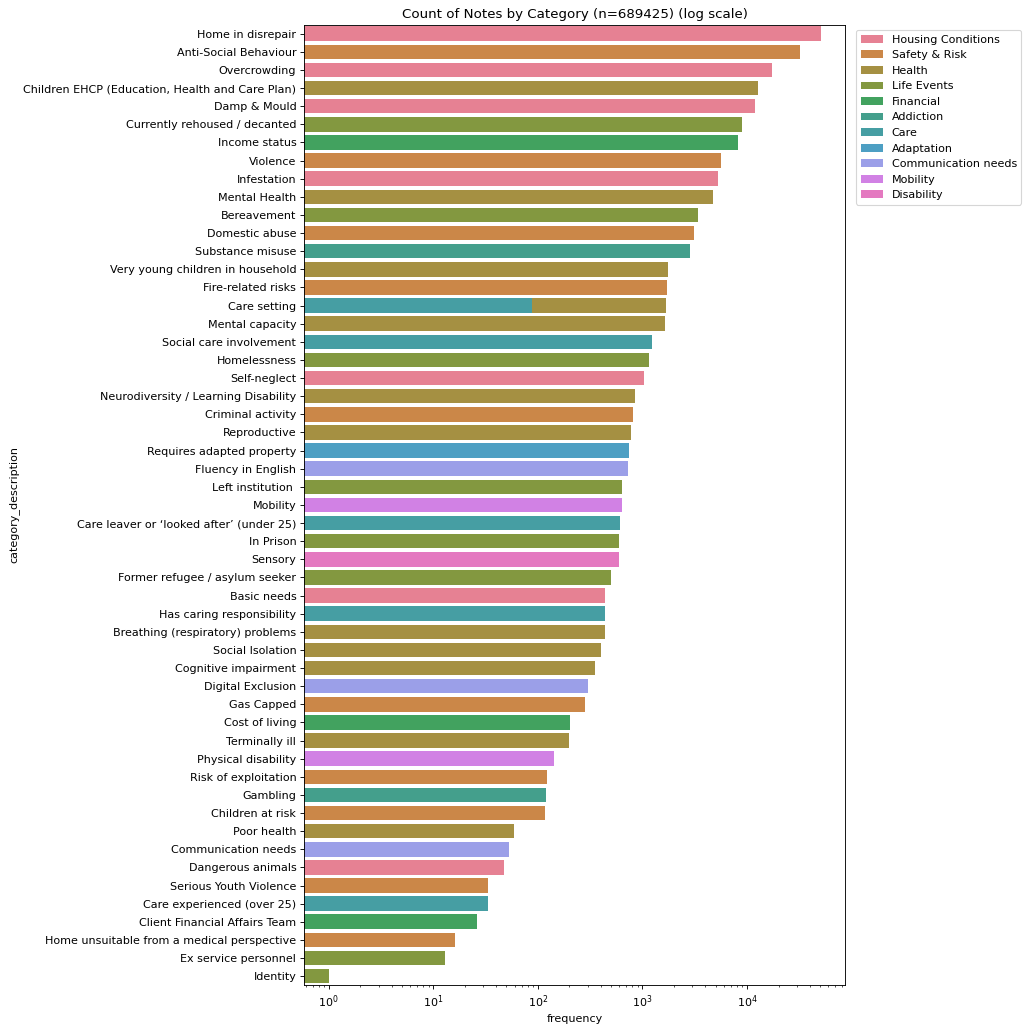

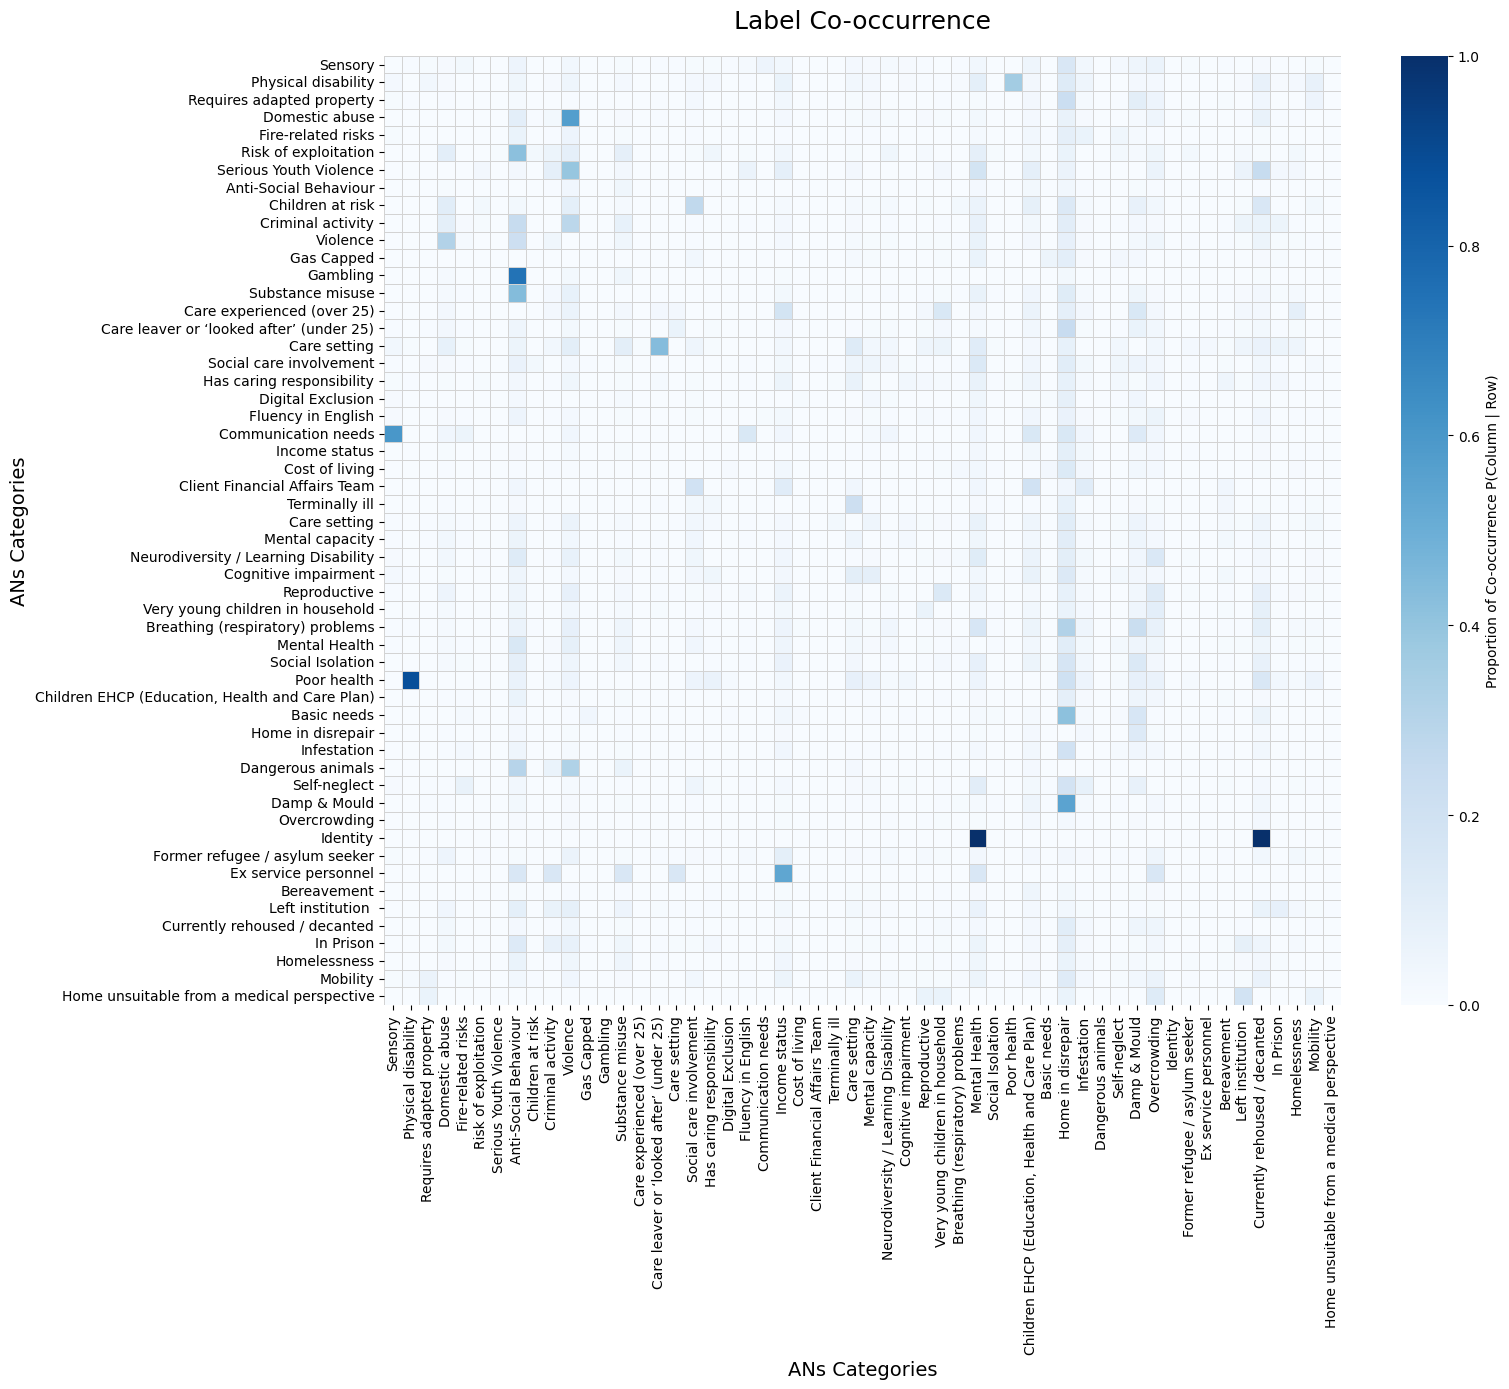

In [27]:
analyze_category_distribution(df, taxonomy)

### Combine & drop rare categories
Based on the EDA, combine or drop categories to address class imbalance and ensure sufficient representation for sampling.

In [28]:
df_v2 = df.copy()
taxonomy_v2 = taxonomy.copy()

combined_categories = {
    'cat_vulnerability_care': [
        'cat_vulnerability_care_care_experienced_over_25',
        'cat_vulnerability_care_care_leaver_or_looked_after_under_25',
        'cat_vulnerability_care_care_setting',
        'cat_vulnerability_health_care_setting'
    ],
    'cat_vulnerability_financial': [
        'cat_vulnerability_financial_income_status',
        'cat_vulnerability_financial_cost_of_living',
        'cat_vulnerability_financial_client_financial_affairs_team',
    ],
    'cat_vulnerability_health_general': [
        'cat_vulnerability_health_poor_health',
        'cat_vulnerability_health_terminally_ill',
    ],
    'cat_vulnerability_mobility': [
        'cat_vulnerability_mobility_mobility',
        'cat_disability_mobility_physical_disability',
    ],
    'cat_service_need_communication': [
        'cat_service_need_communication_needs_communication_needs',
        'cat_vulnerability_communication_needs_fluency_in_english',
        'cat_vulnerability_communication_needs_digital_exclusion',
    ],
    'cat_safety_risk_safety_risk_violence_general': [
        'cat_safety_risk_safety_risk_violence',
        'cat_safety_risk_safety_risk_serious_youth_violence',
    ],
}

# Drop source columns that were combined
dropped_categories = [
    # --- Not prevalent enough ---
    'cat_vulnerability_life_events_identity', # Only one hit. Should drop.
    'cat_vulnerability_life_events_ex_service_personnel', # 13 hits
    'cat_vulnerability_safety_risk_home_unsuitable_from_a_medical_perspective', # 17 hits
    'cat_vulnerability_housing_conditions_dangerous_animals', # 47 hits
    # --- Columns that were combined ---
    *[l for sources in combined_categories.values() for l in sources]
]


for new_label, source_labels in combined_categories.items():
    # Combine bool flags in df
    df_v2[new_label] = df_v2[source_labels].any(axis=1)
    
    # Combine taxonomy labels (concatenate regex & values)
    mask = taxonomy_v2['cat_label'].isin(source_labels)
    combined_regex = '|'.join(taxonomy_v2.loc[mask, 'regex'])
    combined_values = taxonomy_v2.loc[mask, 'values_hint'].sum()  # concatenates lists
    
    new_row = taxonomy_v2[taxonomy_v2['cat_label'] == source_labels[0]].copy()
    new_row['cat_label'] = new_label
    new_row['regex'] = combined_regex
    new_row['values_hint'] = [combined_values]  # wrap in list so pandas doesn't unpack it
    taxonomy_v2 = pd.concat([taxonomy_v2, new_row], ignore_index=True)

df_v2.drop(columns=dropped_categories, inplace=True)
mask = taxonomy_v2['cat_label'].isin(dropped_categories)
taxonomy_v2 = taxonomy_v2[~mask].reset_index(drop=True)

In [29]:
del df # memory saving

In [30]:
# Fixing 'category_description' (pretty parsed) labels
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_vulnerability_care', 'category_description'] = 'Care (General)'
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_vulnerability_financial', 'category_description'] = 'Financial (General)'
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_vulnerability_health_general', 'category_description'] = 'Health (Chronic)'
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_vulnerability_mobility', 'category_description'] = 'Mobility'
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_service_need_comms', 'category_description'] = 'Communication Needs'
taxonomy_v2.loc[taxonomy_v2['cat_label'] == 'cat_safety_risk_safety_risk_violence_general', 'category_description'] = 'Violence Risk'

taxonomy_v2.to_csv("data/output/taxonomy_v2_autogen.csv", index=False)

taxonomy_v2.head()

,top_level_category,high_level_category,category_description,values_hint,high_level_cat_label,cat_label,regex
0,Disability,Disability,Sensory,"[Deaf, Hearing impairment, Visually impaired, ...",cat_disability_disability,cat_disability_disability_sensory,\bdeaf\b|\bBSL\b|\bhearing (?:loss|impairment|...
1,Disability,Adaptation,Requires adapted property,"[Minor adaptations, Major adaptation]",cat_disability_adaptation,cat_disability_adaptation_requires_adapted_pro...,\bstairlift\b|\bwet room\b|\blevel access\b|\b...
2,Safety & Risk,Safety & Risk,Domestic abuse,"[Alleged Perpetrator, Survivor]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_domestic_abuse,\bdomestic abuse\b|\bdomestic violence\b|\bDV\...
3,Safety & Risk,Safety & Risk,Fire-related risks,"[Arson, Fire hazards in the house]",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_firerelated_risks,\barson\b|\bfire hazard\b|\bfire risk\b|\bfire...
4,Safety & Risk,Safety & Risk,Risk of exploitation,"[Financial, Sexual, Criminal, Cuckooing, Radic...",cat_safety_risk_safety_risk,cat_safety_risk_safety_risk_risk_of_exploitation,\bcuckooing\b|\bfinancial (?:exploitation|abus...


### Compare class imbalance
Compare the class imbalance before and after combining/dropping categories to assess the impact on the dataset.

,label,IRLbl
0,Home in disrepair,1.000000
1,Anti-Social Behaviour,1.582967
2,Overcrowding,2.898270
3,"Children EHCP (Education, Health and Care Plan)",3.950102
4,Damp & Mould,4.262277
5,Currently rehoused / decanted,5.622366
6,Financial (General),5.976179
7,Violence Risk,8.903072
8,Infestation,9.491248
9,Mental Health,10.713193


,Metric,Value
0,MeanIR,82.91
1,MaxIR,434.72
2,CVIR,1.32


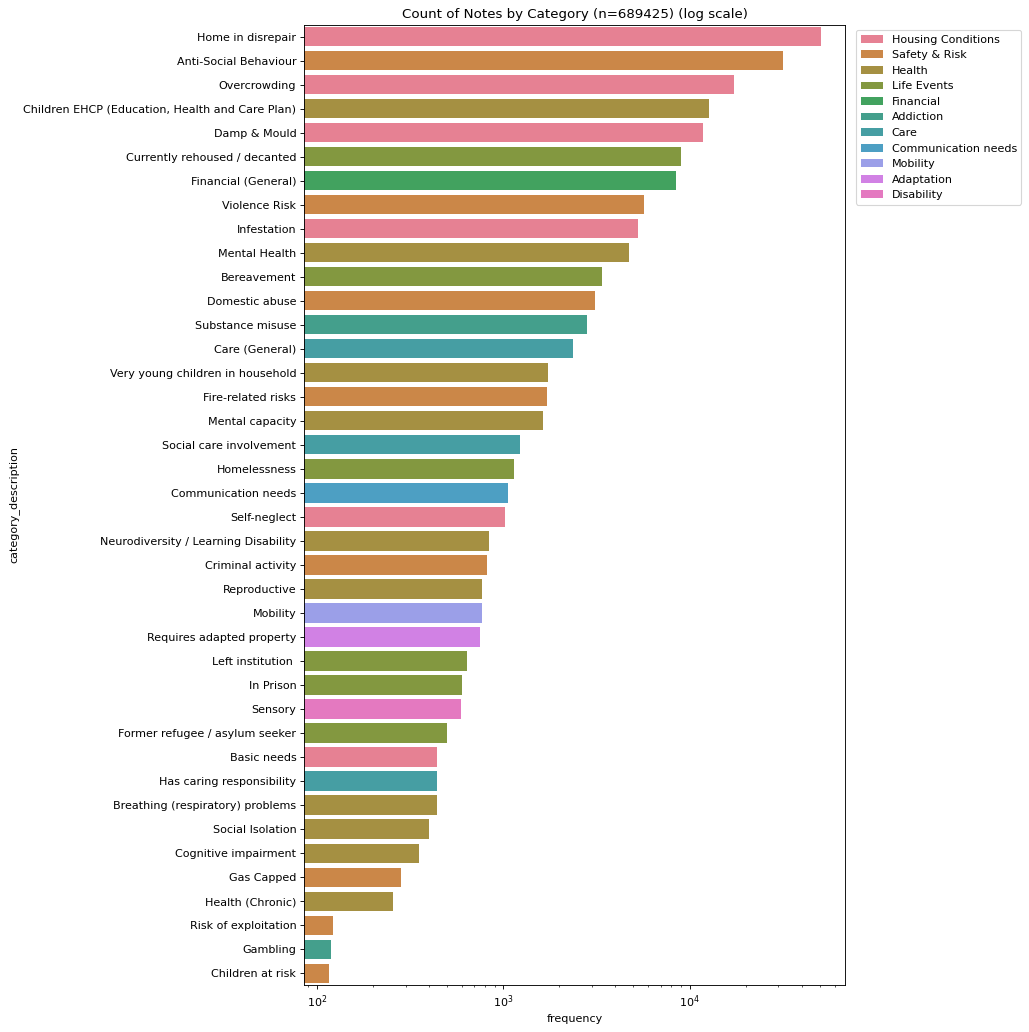

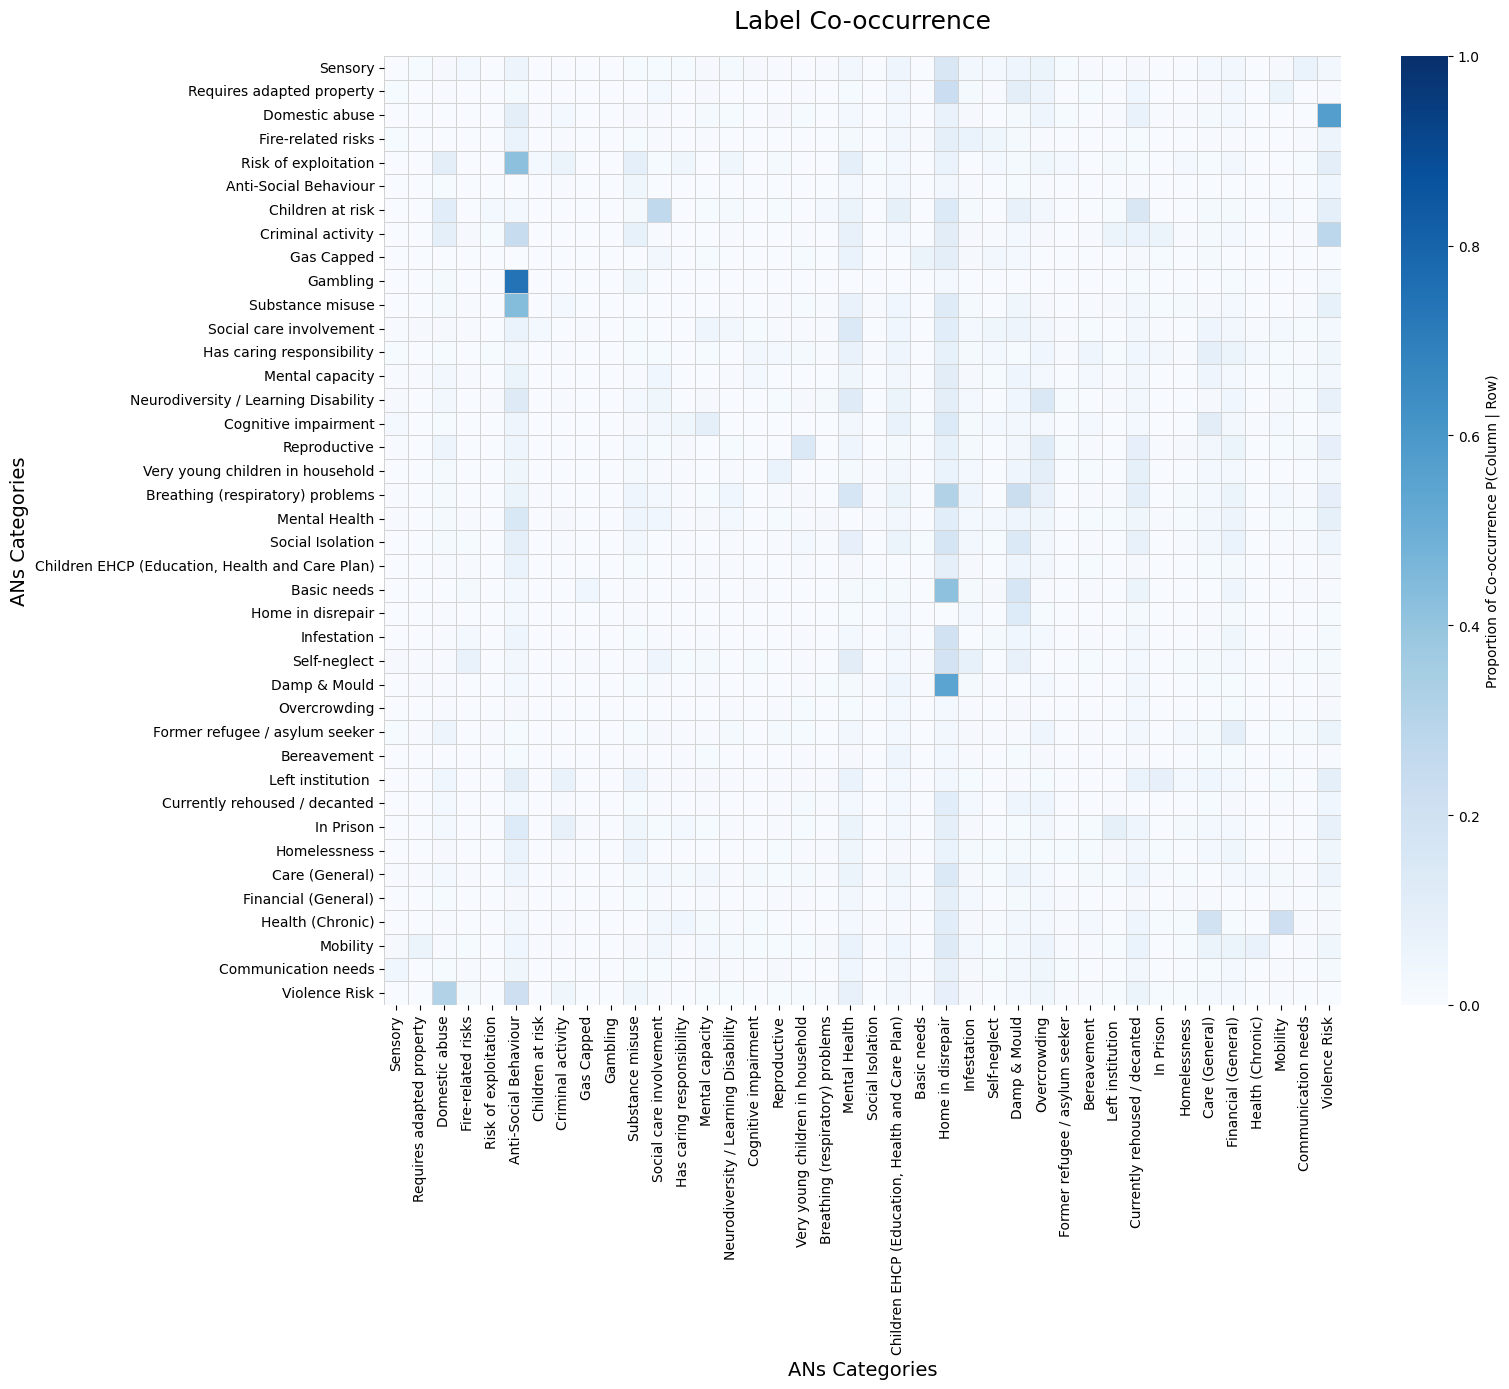

In [31]:
analyze_category_distribution(df_v2, taxonomy_v2)

## Construct Gold Standard Set
TODO explanation

### Stratified Sample (n=2000)
Perform stratified sampling based on the weak labels to create a balanced gold standard dataset of 2000 records for manual annotation.

In [32]:
# Get unflagged records - zero category matches.
df_v2['unflagged'] = ~df_v2[taxonomy_v2['cat_label']].any(axis=1)
df_v2['unflagged'].value_counts()

unflagged
True     535828
False    153597
Name: count, dtype: int64

In [33]:
sampled_data = []
sampled_ids = set()

# Sample categories by least prevalent (up to TARGET_PER_CAT)
category_counts = df_v2[taxonomy_v2['cat_label']].sum().sort_values(ascending=True)
for cat in category_counts.index:
    pool = df_v2[df_v2[cat] & ~df_v2['note_id'].isin(sampled_ids)] # In the category and not already sampled
    n = min(len(pool), TARGET_PER_CAT)
    if n > 0:
        sample = pool.sample(n=n, random_state=RANDOM_STATE)
        sampled_data.append(sample)
        sampled_ids.update(sample['note_id'].tolist())

# Sample unflagged (non-category matches) records
pool = df_v2[df_v2['unflagged'] & ~df_v2['note_id'].isin(sampled_ids)]
n = min(len(pool), TARGET_TOTAL - len(sampled_ids))
if n > 0:
    sample = pool.sample(n=n, random_state=RANDOM_STATE)
    sampled_data.append(sample)
    sampled_ids.update(sample['note_id'].tolist())

# Combine and shuffle
final_sample = pd.concat(sampled_data).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [34]:
final_sample.drop(columns=['note_id', 'note_content', 'note_category']).sum().sort_values()

cat_vulnerability_addiction_gambling                                      45
cat_safety_risk_safety_risk_risk_of_exploitation                          46
cat_safety_risk_safety_risk_gas_capped                                    46
cat_vulnerability_health_cognitive_impairment                             47
cat_safety_risk_safety_risk_children_at_risk                              48
cat_vulnerability_housing_conditions_basic_needs                          49
cat_vulnerability_health_social_isolation                                 50
cat_safety_risk_safety_risk_firerelated_risks                             50
cat_vulnerability_health_general                                          50
cat_vulnerability_health_breathing_respiratory_problems                   51
cat_vulnerability_life_events_homelessness                                52
cat_disability_adaptation_requires_adapted_property                       53
cat_service_need_communication                                            55

In [35]:
del df_v2 # Memory saving

### Compare class imbalance
Compare the class imbalance in the gold standard set to the original dataset to evaluate the effectiveness of the sampling strategy.

,label,IRLbl
0,Home in disrepair,1.000000
1,Anti-Social Behaviour,1.395238
2,Violence Risk,1.966443
3,Mental Health,2.006849
4,Damp & Mould,2.138686
5,Currently rehoused / decanted,2.421488
6,Overcrowding,2.712963
7,Financial (General),2.844660
8,Domestic abuse,2.930000
9,Care (General),3.020619


,Metric,Value
0,MeanIR,4.41
1,MaxIR,6.51
2,CVIR,0.35


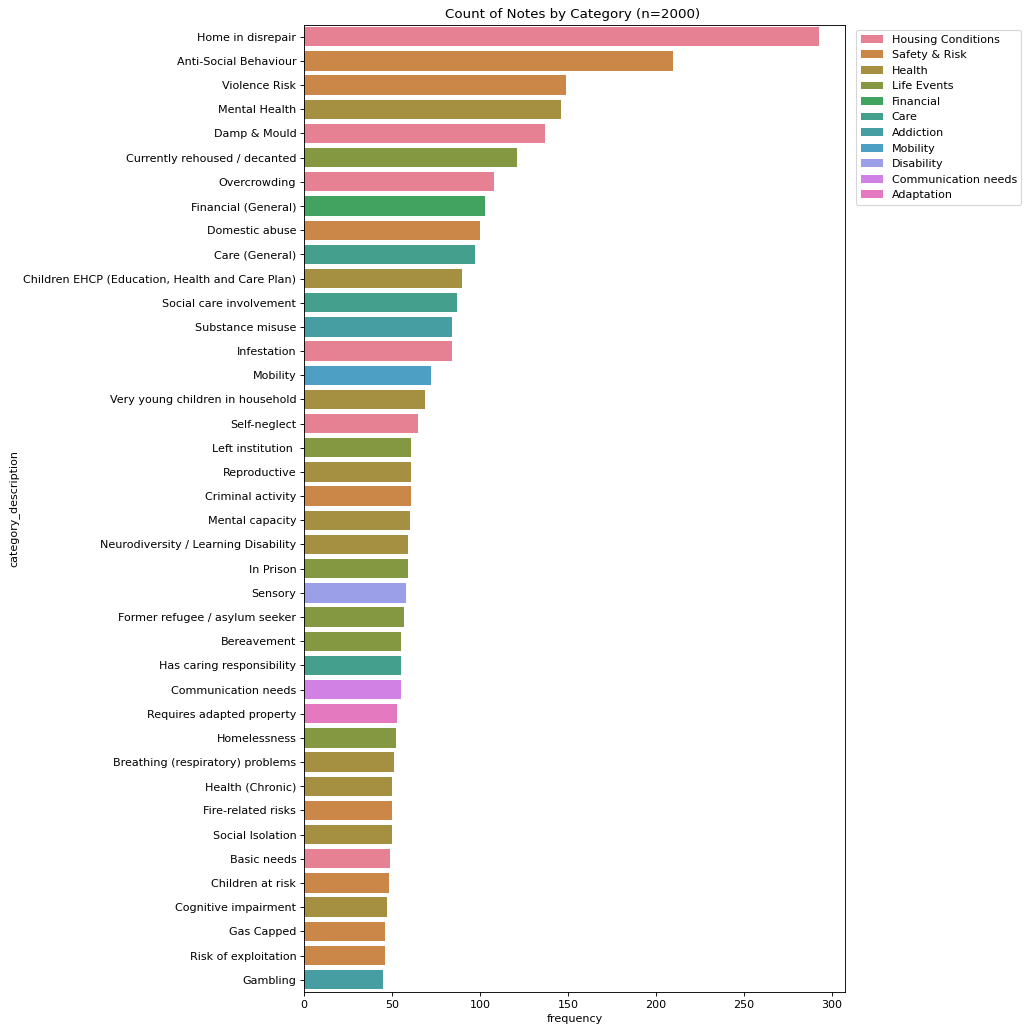

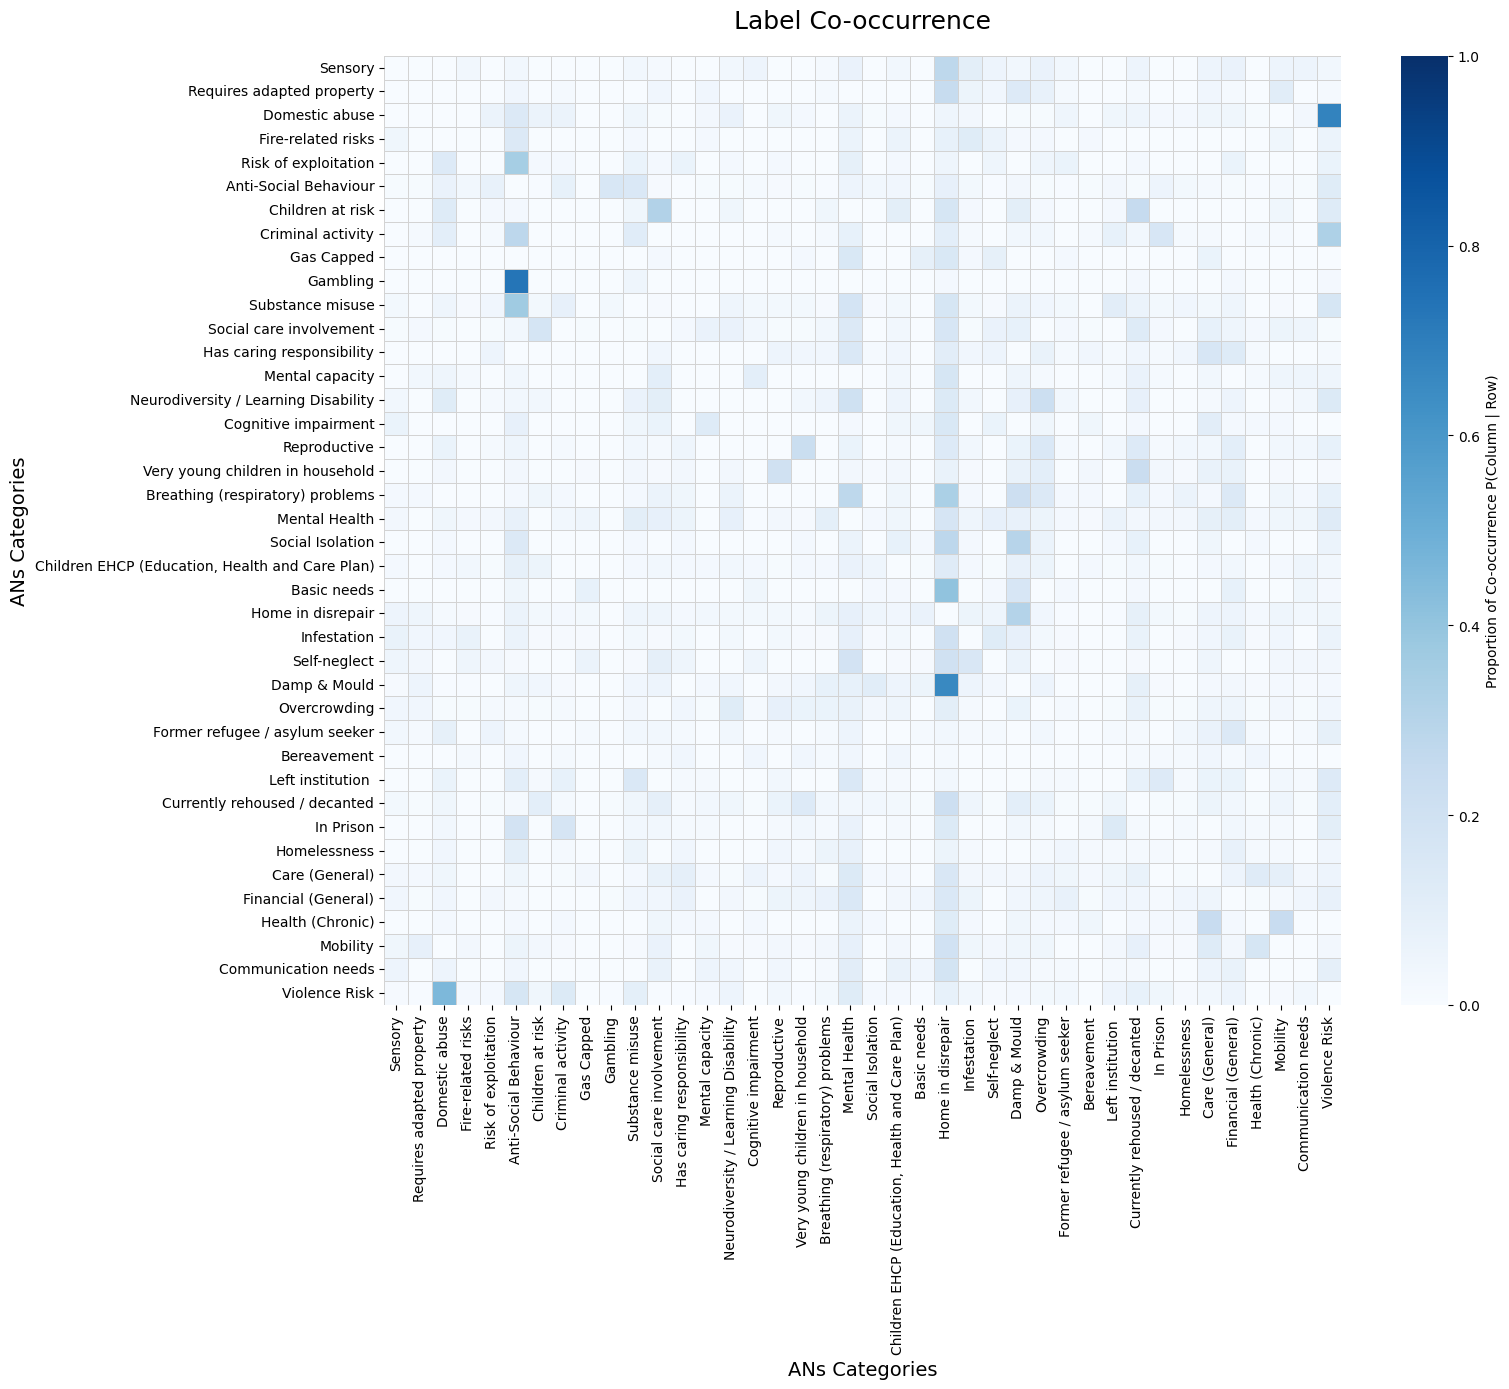

In [36]:
analyze_category_distribution(final_sample, taxonomy_v2, log_scale=False)

### PII (Personally-Identifiable Information) Redaction
Apply PII redaction techniques to the gold standard dataset to ensure privacy and compliance with GDPR before manually annotating.

In [37]:
# Set up engines
fake = Faker('en-GB')
Faker.seed(RANDOM_STATE)

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

In [38]:
# Regex matcher for UK postcodes
uk_postcode_pattern = Pattern(
    name="uk_postcode_regex", 
    regex=r"\b([Gg][Ii][Rr] 0[Aa]{2})|((([A-Za-z][0-9]{1,2})|(([A-Za-z][A-Ha-hJ-Yj-y][0-9]{1,2})|(([A-Za-z][0-9][A-Za-z])|([A-Za-z][A-Ha-hJ-Yj-y][0-9][A-Za-z]?))))\s?[0-9][A-Za-z]{2})\b", 
    score=0.85
)
uk_postcode_recognizer = PatternRecognizer(
    supported_entity="UK_POSTCODE", 
    patterns=[uk_postcode_pattern]
)
analyzer.registry.add_recognizer(uk_postcode_recognizer)

In [39]:
# Define target entities to redact
target_entities = [
    "PERSON", 
    "EMAIL_ADDRESS", 
    "PHONE_NUMBER", 
    "DATE_TIME",
    "LOCATION",
    "UK_POSTCODE", 
    "CREDIT_CARD", 
    "IBAN_CODE", 
    "IP_ADDRESS",
    "URL"
]

# Replace names with fake names
consistent_name_map = {}
def get_consistent_fake_name(text):
    if text not in consistent_name_map:
        consistent_name_map[text] = fake.name()
    return consistent_name_map[text]

# Define operator for each entity type
operators = {
    "PERSON": OperatorConfig("custom", {"lambda": get_consistent_fake_name}),
    "DEFAULT": OperatorConfig("replace") # Automatically replaces with e.g., <PHONE_NUMBER>
}

In [40]:
# Track what was found and replaced per note
def anonymize_and_extract_spans(text):
    if not isinstance(text, str):
        return pd.Series({'note_content': text, 'fake_name_spans': []})
        
    # Analyze
    results = analyzer.analyze(text=text, entities=target_entities, language='en')
    
    # Anonymize
    anonymized = anonymizer.anonymize(
        text=text,
        analyzer_results=results,
        operators=operators
    )
    
    fake_spans = []
    for item in anonymized.items:
        if item.entity_type == 'PERSON':
            # Highlight replaced names as fake
            fake_spans.append({
                'start': item.start,
                'end': item.end,
                'text': item.text, 
                'labels': ['Pseudonym'] 
            })
    
    return pd.Series({
        'note_content': anonymized.text,
        'fake_name_spans': fake_spans
    })



tqdm.pandas() # Enable pandas progress_apply (for progress bar)
scrubbed_df = final_sample.copy()
scrubbed_df[['note_content', 'fake_name_spans']] = scrubbed_df['note_content'].progress_apply(anonymize_and_extract_spans)

100%|██████████| 2000/2000 [00:44<00:00, 45.22it/s]


In [50]:
with open(f"data/output/consistent_name_map_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.json", "w") as f:
    json.dump(consistent_name_map, f, indent=2)

### Pre-Annotation
Pre-annotate the category spans, pseudonyms, and entity referencee (pronouns and role such as tenant). This will speed up manual annoation.

In [42]:
# Construct regexes for ANs & entities 
entity_regex_dict = {
    "Pronoun": r"(?i)\b(he|him|his|she|her|hers|they|them|their)\b", # standard pronouns
    "Descriptive Role": r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant|neighbour|neighbor|neighbours|neighbor)\b" # common housing roles
}
compiled_category_regex = {row.cat_label: re.compile(row.regex) for row in taxonomy_v2.itertuples()}
compiled_entity_regex = {ent: re.compile(pattern) for ent, pattern in entity_regex_dict.items()}

In [43]:
# Loop through cleaned sample

label_studio_tasks = []
for index, row in tqdm(scrubbed_df.iterrows()):
    note_content = str(row['note_content'])
    note_id = str(row['note_id'])
    
    identified_labels = []
    
    # --- AN Tags ---
    for cat_key, compiled_regex in compiled_category_regex.items():
        for match in compiled_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "need_labels",  # Matches Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(), # Extract the specific span - didn't do with the whole dataset as it is expensive.
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [cat_key]
                }
            })

    # --- Entity Labels (Pronouns/Roles) ---
    for entity_label, compiled_regex in compiled_entity_regex.items():
        for match in compiled_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "entity_labels",  # Matches Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [entity_label]
                }
            })

    # --- Fake name Spans (Presidio) ---
    for span in row['fake_name_spans']:
        identified_labels.append({
            "from_name": "entity_labels", # Matches Label Studio XML
            "to_name": "text",
            "type": "labels",
            "value": {
                "start": span['start'],
                "end": span['end'],
                "text": span['text'],
                "labels": span['labels']
            }
        })
    
    # --- Construct label studio task ---
    task = {
        "data": {
            "note_content": note_content,
            "id": note_id
        },
        "predictions": [{
            "model_version": "pre_annotated",
            "score": 1.0,
            "result": identified_labels
        }]
    }
    
    label_studio_tasks.append(task)

len(label_studio_tasks)

2000it [00:01, 1459.74it/s]


2000

In [44]:
label_studio_tasks[:2]

[{'data': {'note_content': '[Category: Tenancy Management] Call Summary; Caller: Abdul Hopkins Tete D; Logged by: Lesley Wilson-Newman; Rent: Account query; balance and shortfall provided',
   'id': '8b69cab2-f1e2-a627-2e97-784fac3fbd8c'},
  'predictions': [{'model_version': 'pre_annotated',
    'score': 1.0,
    'result': [{'from_name': 'entity_labels',
      'to_name': 'text',
      'type': 'labels',
      'value': {'start': 45,
       'end': 51,
       'text': 'Caller',
       'labels': ['Descriptive Role']}},
     {'from_name': 'entity_labels',
      'to_name': 'text',
      'type': 'labels',
      'value': {'start': 86,
       'end': 106,
       'text': 'Lesley Wilson-Newman',
       'labels': ['Pseudonym']}},
     {'from_name': 'entity_labels',
      'to_name': 'text',
      'type': 'labels',
      'value': {'start': 53,
       'end': 66,
       'text': 'Abdul Hopkins',
       'labels': ['Pseudonym']}}]}]},
 {'data': {'note_content': '[Category: Tenure management] DO NOT <URL>Mrs

### Export sample set

In [48]:
with open(f"data/output/label_studio_pre_annotated_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.json", "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

In [49]:
scrubbed_df.to_csv(f'data/output/balanced_sample_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.csv', index=False) # backup - does not have pre-annotations